# Bibliotekos

In [809]:
import pandas as pd
import numpy as np
import torch
torch.cuda.is_available()
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
from skorch import NeuralNetRegressor
from skorch.callbacks import Checkpoint, EarlyStopping
from skorch.dataset import ValidSplit

from Lasso2 import select_features_lasso

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.base import BaseEstimator, RegressorMixin
from skorch import NeuralNetRegressor

from sklearn.metrics import make_scorer, root_mean_squared_error

# Duomenų paruošimas

In [810]:
data = pd.read_csv("../datasets_prep/dm_project_dataset.csv")

data['observationTime'] = pd.to_datetime(data['observationTime'])
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

lag_config = {
    'absorbing_aerosol_index': [8],
    'H2O_column_number_density': [1],
    'NO2_column_number_density': [1, 2],
    'stratospheric_NO2_column_number_density': [1, 3, 7],
    'NO2_slant_column_number_density': [1, 2],
    'tropopause_pressure': [1],
    'nmvoc': [1, 2],
    'nh3': [1, 11],
    'pm10': [1, 11],
    'sia': [11],
    'pans': [10],
    'dust': [1, 4],
    'pm2p5': [1, 11],
    'NO2': [1, 4, 9],

    # METEO
    'airTemperature': [1, 3, 9, 10],
    'seaLevelPressure': [1, 2],
    'relativeHumidity': [1, 2],
    'xgb_cloudCover': [1, 2],
    'windSpeed_fixed': [1, 2, 3],
    'windGust_fixed': [1, 2],
    'windDirection_fixed': [4, 10]
}

for feature, lags in lag_config.items():
    for lag in lags:
        data[f'{feature}_lag{lag}'] = data[feature].shift(lag)

# data['target'] = data['missforest_precipitation'].shift(-1)
data = data.dropna()

drop_names = [
    'observationTime',
    # 'absorbing_aerosol_index',
    # 'NO2_column_number_density',
    # 'stratospheric_NO2_column_number_density',
    # 'NO2_slant_column_number_density',
    # 'tropopause_pressure',
    # 'H2O_column_number_density',
    # 'BrO',
    # 'BrO_Error',
    # 'NO2',
    # 'NO2_Error',
    # 'O3',
    # 'O3_Error',
    # 'pm10',
    # 'pm2p5',
    # 'sia',
    # 'nmvoc',
    # 'dust',
    # 'nh3',
    # 'pans',
    # 'tp',
    # 't2m',
    # 'airTemperature',
    # 'seaLevelPressure',
    # 'relativeHumidity',
    # 'missforest_precipitation',
    # 'xgb_cloudCover',
    # 'feelsLikeTemperature_fixed',
    # 'windSpeed_fixed',
    # 'windGust_fixed',
    # 'windDirection_fixed',
    # 'month_cos',
    # 'month_sin',
    # 'month',
    # 'day_of_year'
]

# X = data.drop(columns=drop_names)
X = data
# y = data['target']

In [811]:
X.head()

,observationTime,absorbing_aerosol_index,NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,H2O_column_number_density,BrO,BrO_Error,NO2,...,relativeHumidity_lag2,xgb_cloudCover_lag1,xgb_cloudCover_lag2,windSpeed_fixed_lag1,windSpeed_fixed_lag2,windSpeed_fixed_lag3,windGust_fixed_lag1,windGust_fixed_lag2,windDirection_fixed_lag4,windDirection_fixed_lag10
11,2018-07-12,-1.259574,0.000091,0.000061,0.000205,19223.746,2092.265400,1.413290e+13,1.937367e+13,3.779792e+15,...,72.416667,53.916667,65.916667,0.879167,0.891667,2.462500,8.7,6.2,315.0,327.0
12,2018-07-13,-1.214123,0.000084,0.000065,0.000208,19219.334,2178.943600,3.610126e+13,1.652258e+13,3.688520e+15,...,79.083333,46.541667,53.916667,1.495833,0.879167,0.891667,10.8,8.7,294.0,271.0
13,2018-07-14,-0.762476,0.000079,0.000063,0.000203,19222.883,2346.339133,3.659979e+13,1.520030e+13,4.186392e+15,...,76.166667,82.583333,46.541667,1.270833,1.495833,0.879167,8.0,10.8,5.0,288.0
14,2018-07-15,-1.098520,0.000090,0.000057,0.000149,16677.404,2322.217746,3.449885e+13,1.453966e+13,3.940498e+15,...,84.541667,83.478261,82.583333,0.645833,1.270833,1.495833,6.6,8.0,2.0,293.0
15,2018-07-16,-0.770874,0.000077,0.000062,0.000183,16673.053,2747.987500,3.512158e+13,1.647380e+13,3.581072e+15,...,87.625000,69.708333,83.478261,1.270833,0.645833,1.270833,6.1,6.6,127.0,275.0


# SSA

In [812]:
# ── LeakFreeSSA: fits eigenvectors on train only ────────────────────────────

class LeakFreeSSA:
    """
    Singular Spectrum Analysis with strict separation of fit and transform.

    fit(train_series)
        Builds trajectory matrix from train only, computes eigenvectors U_.

    transform_train(train_series)
        Reconstructs all components for the training series.

    transform_test(train_series, test_series)
        For each test point, reconstructs using [train + test_so_far] context
        but projects onto the TRAIN eigenvectors only.
        Returns components of shape (n_components, len(test_series)).
    """

    def __init__(self, window_size: int = 10, n_components: int = 10):
        self.L = window_size
        self.n_components = n_components

    def _trajectory_matrix(self, series: np.ndarray) -> np.ndarray:
        """Build the (L × K) Hankel trajectory matrix."""
        K = len(series) - self.L + 1
        return np.array([series[i: i + self.L] for i in range(K)]).T  # (L, K)

    def fit(self, series: np.ndarray):
        """Compute and store eigenvectors from train series."""
        X = self._trajectory_matrix(series)          # (L, K)
        S = X @ X.T                                  # (L, L)
        eigenvalues, eigenvectors = np.linalg.eigh(S)
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues_ = eigenvalues[idx]
        self.U_ = eigenvectors[:, idx][:, :self.n_components]  # (L, n_comp)
        return self

    def _reconstruct(self, series: np.ndarray) -> np.ndarray:
        """Project series onto stored eigenvectors and diagonal-average back."""
        N = len(series)
        K = N - self.L + 1
        X = self._trajectory_matrix(series)          # (L, K)
        components = np.zeros((self.n_components, N))
        for i in range(self.n_components):
            u  = self.U_[:, i]                       # (L,)
            v  = u @ X                               # (K,)
            Xi = np.outer(u, v)                      # (L, K)
            comp  = np.zeros(N)
            count = np.zeros(N)
            for col in range(K):
                for row in range(self.L):
                    t = row + col
                    comp[t]  += Xi[row, col]
                    count[t] += 1
            components[i] = comp / count
        return components

    def transform_train(self, series: np.ndarray) -> np.ndarray:
        return self._reconstruct(series)

    def transform_test(self, train_series, test_series):
        N_test = len(test_series)
        result = np.zeros((self.n_components, N_test))
        
        for t in range(N_test):
            # Only use train + test up to and including day t
            context = np.concatenate([train_series, test_series[:t+1]])
            comps = self._reconstruct(context)
            # Take only the last value (today's reconstruction)
            result[:, t] = comps[:, -1]
        
        return result


# ── Exploratory SSA on the train series only (for visualisation) ─────────────
series_full_log = np.log1p(data['missforest_precipitation'].values)

L      = 10
N_COMP = 10

split_idx_explore = int(len(data) * 0.9)
train_series_explore = series_full_log[:split_idx_explore]

ssa_explore = LeakFreeSSA(window_size=L, n_components=N_COMP)
ssa_explore.fit(train_series_explore)
components = ssa_explore.transform_train(train_series_explore)

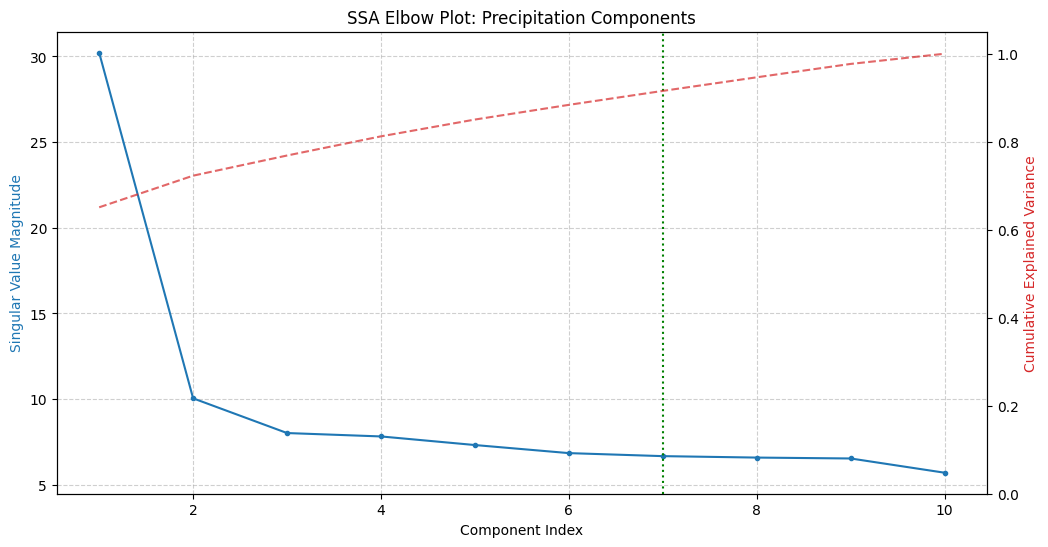

In [813]:
component_energies = np.array([np.sum(c**2) for c in components])
singular_values = np.sqrt(component_energies)

# 2. Sort them (SSA components are usually already sorted)
idx = np.argsort(singular_values)[::-1]
singular_values = singular_values[idx]

# 3. Calculate Variance Explained
total_var = np.sum(singular_values**2)
explained_variance = (singular_values**2) / total_var
cumulative_variance = np.cumsum(explained_variance)

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Singular Values (The Elbow)
ax1.plot(range(1, L + 1), singular_values, marker='o', markersize=3, color='tab:blue', label='Singular Values')
ax1.set_xlabel('Component Index')
ax1.set_ylabel('Singular Value Magnitude', color='tab:blue')
ax1.set_title('SSA Elbow Plot: Precipitation Components')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Cumulative Variance (To see how much info you keep)
ax2 = ax1.twinx()
ax2.plot(range(1, L + 1), cumulative_variance, color='tab:red', linestyle='--', alpha=0.7, label='Cumulative Variance')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
ax2.set_ylim(0, 1.05)

# Add a vertical line at a suggested cutoff (e.g., where 90% variance is reached)
cutoff_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
ax1.axvline(x=cutoff_90, color='green', linestyle=':', label=f'90% Var ({cutoff_90} comps)')

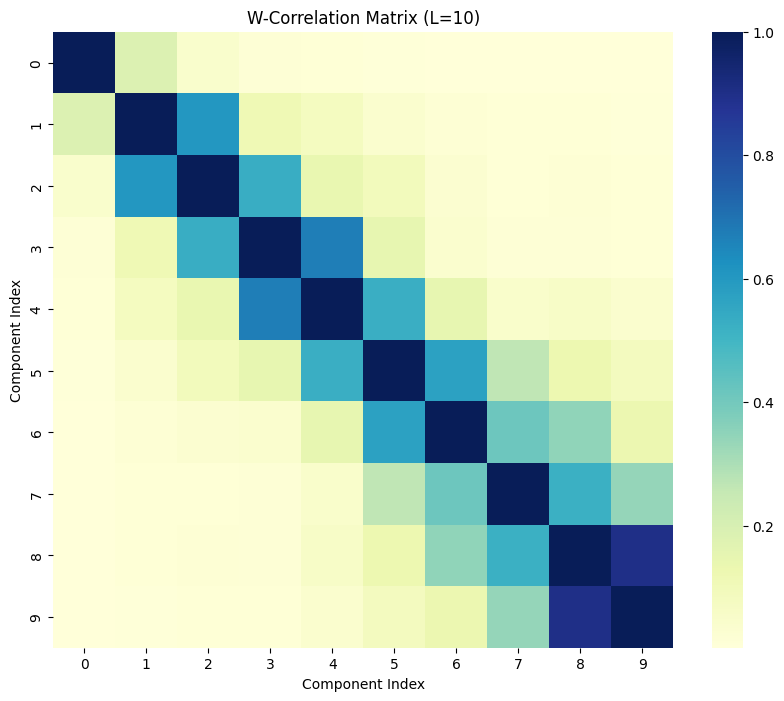

In [814]:
def plot_w_correlation(components):
    L, N = components.shape
    # Define the weights (w_i)
    # This reflects how many times each observation was used in the trajectory matrix
    K = N - L + 1
    w = np.array([min(i + 1, L, N - i) for i in range(N)])
    
    w_corr = np.zeros((L, L))
    
    # Calculate weighted norms once for efficiency
    weighted_norms = [np.sqrt(np.sum(w * (c**2))) for c in components]
    
    for i in range(L):
        for j in range(i, L):
            numerator = np.sum(w * components[i] * components[j])
            denominator = weighted_norms[i] * weighted_norms[j]
            val = abs(numerator / denominator)
            w_corr[i, j] = val
            w_corr[j, i] = val # Matrix is symmetric
            
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(w_corr, cmap='YlGnBu', annot=False)
    plt.title(f'W-Correlation Matrix (L={L})')
    plt.xlabel('Component Index')
    plt.ylabel('Component Index')
    plt.show()
    
    return w_corr

# Use it on your first 20-30 components (plotting 365 is too dense to read)
w_matrix = plot_w_correlation(components[:120])

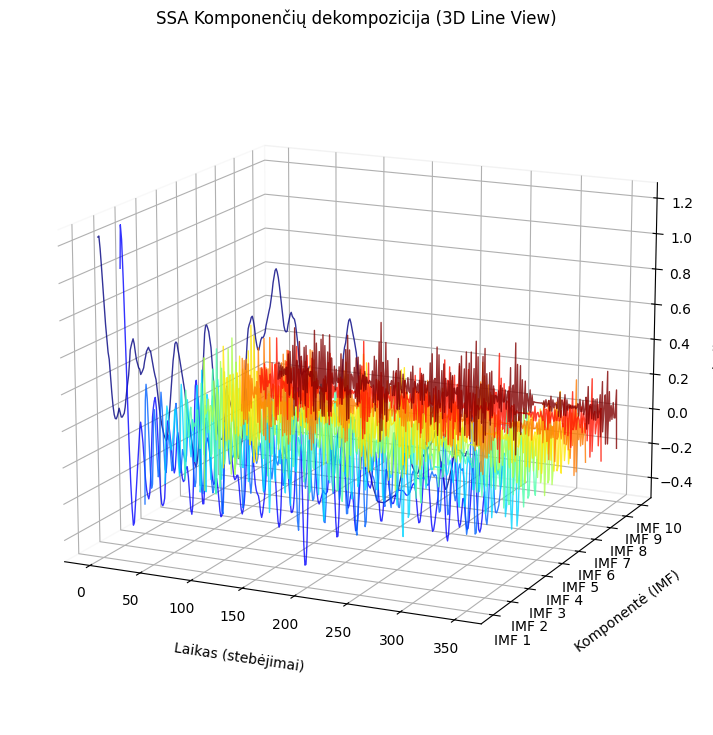

In [815]:
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')
# Nustatome segmentą vizualizacijai (pvz., pirmos 1500 valandų)
n_points = min(350, len(train_series_explore))
x = np.arange(n_points)
zs = np.arange(N_COMP)

# Spalvų paletė
colors = plt.cm.jet(np.linspace(0, 1, N_COMP))

for i in range(N_COMP):
    y = components[i][:n_points]
    ax.plot(x, [i] * n_points, y, color=colors[i], linewidth=1, alpha=0.8)

ax.set_xlabel('Laikas (stebėjimai)', labelpad=15)
ax.set_ylabel('Komponentė (IMF)', labelpad=15)
ax.set_zlabel('Krituliai (mm)', labelpad=10)

ax.view_init(elev=15, azim=-65)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.set_yticks(zs)
ax.set_yticklabels([f'IMF {i+1}' for i in zs])

plt.title("SSA Komponenčių dekompozicija (3D Line View)")
plt.show()

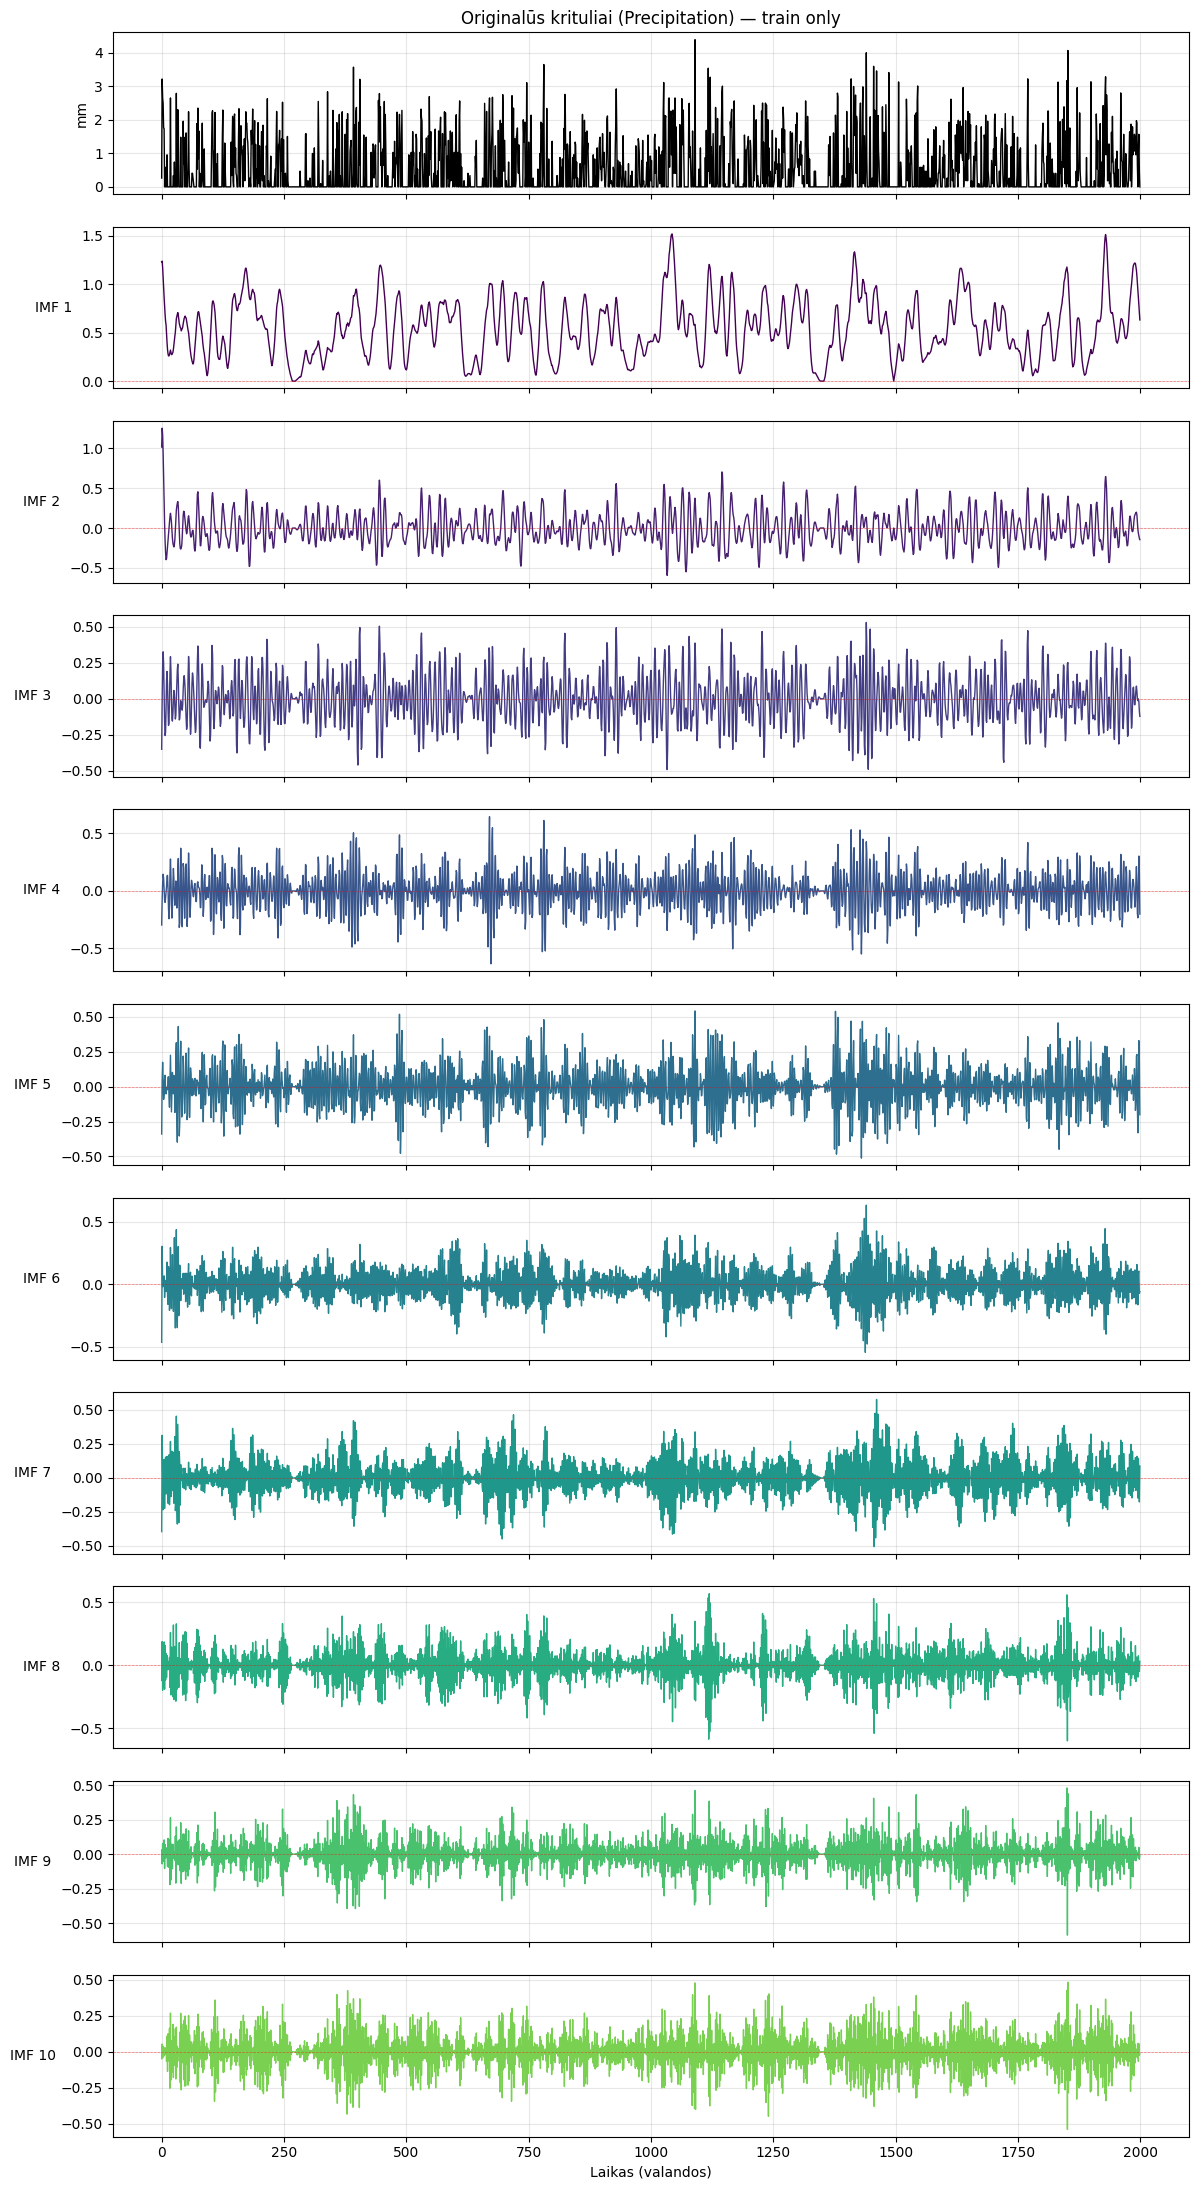

In [816]:
N = 10

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

n_points = min(2000, len(train_series_explore))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, train_series_explore[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation) — train only', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, components[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('Laikas (valandos)')
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.show()

In [817]:
how_group = {
    '1': [0],
    '2': [1],
    '3': [2],
    '4': [3],
    '5': [4],
    '6': [5],
    '7': [6],
    '8': [7, 8, 9],
}

# how_group = {
#     '1': [0],
#     '2': [1],
#     '3': [2],
#     '4': [3, 4],
#     '5': [5],
#     '6': [6, 7, 8, 9],
#     '7': [10, 11, 12],
#     '8': np.arange(13, 120, 1)
# }

# Build grouped components for the EXPLORATORY visualisation (train only)
grouped = []
for key in how_group:
    new_comp = np.zeros_like(components[0])
    for idx in how_group[key]:
        new_comp += components[idx]
    grouped.append(new_comp)

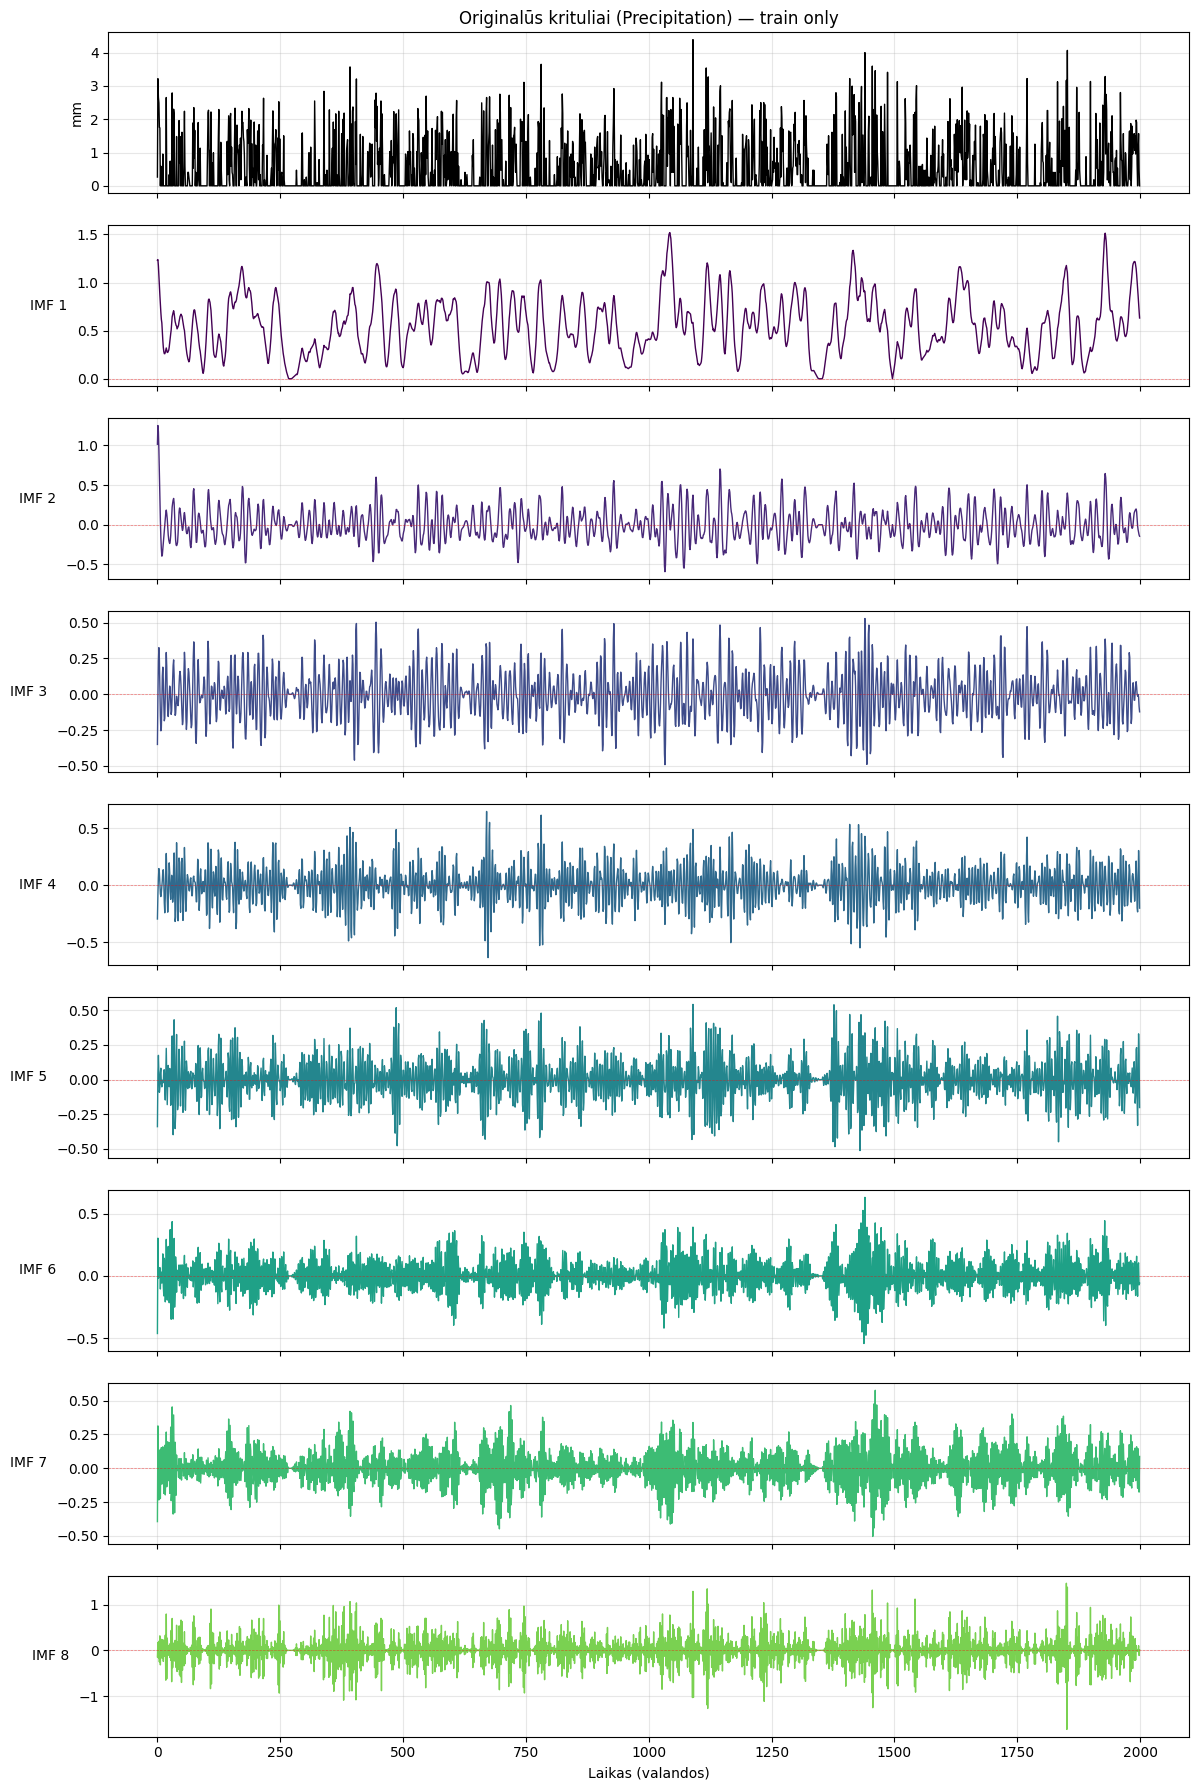

In [818]:
N = 8

fig, axes = plt.subplots(N + 1, 1, figsize=(12, 2 * (N + 1)), sharex=True)

n_points = min(2000, len(train_series_explore))
time_axis = np.arange(n_points)

# Viršutinis grafikas - Originalūs duomenys
axes[0].plot(time_axis, train_series_explore[:n_points], color='black', linewidth=1)
axes[0].set_title('Originalūs krituliai (Precipitation) — train only', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('mm')

colors = plt.cm.viridis(np.linspace(0, 0.8, N))

for i in range(N):
    ax = axes[i + 1]
    ax.plot(time_axis, grouped[i][:n_points], color=colors[i], linewidth=1)
    ax.set_ylabel(f'IMF {i+1}', rotation=0, labelpad=20, verticalalignment='center')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='red', linestyle='--', linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel('Laikas (valandos)')
plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.show()

# SSA Mokymo testavimo aibės — leakage-free

## Skirstymas

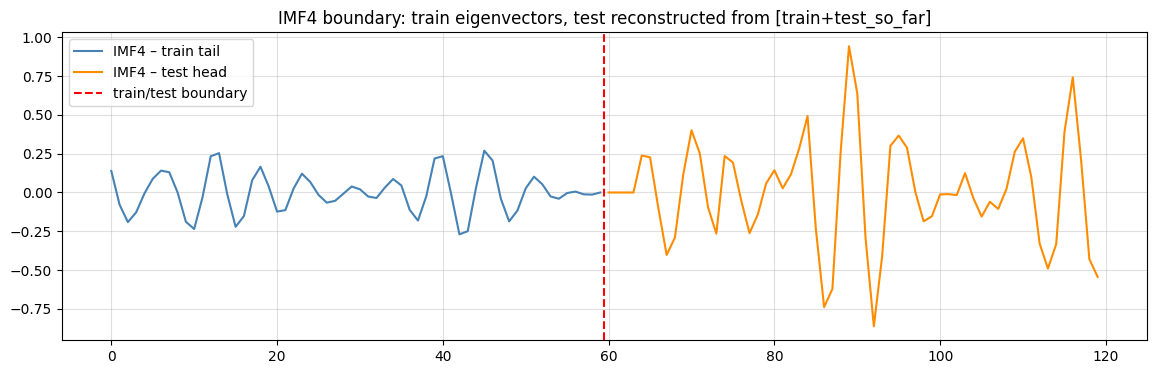

In [819]:
# ── 1. Split BEFORE any SSA ──────────────────────────────────────────────────
split_idx = int(len(X) * 0.9)

X_train_raw = X.iloc[:split_idx].copy()
X_test_raw  = X.iloc[split_idx:].copy()

# ── 2. Log-transform target series ───────────────────────────────────────────
train_series = np.log1p(X_train_raw['missforest_precipitation'].values)
test_series  = np.log1p(X_test_raw['missforest_precipitation'].values)

# ── 3. Fit SSA on TRAIN only ──────────────────────────────────────────────────
ssa = LeakFreeSSA(window_size=L, n_components=N_COMP)
ssa.fit(train_series)

# ── 4. Reconstruct components ─────────────────────────────────────────────────
#   Train: eigenvectors were fitted here — fully leak-free
#   Test : prepend full train for boundary context, project on TRAIN eigenvectors,
#          slice off only the test portion → no future values involved
train_components = ssa.transform_train(train_series)          # (N_COMP, N_train)
test_components  = ssa.transform_test(train_series,           # (N_COMP, N_test)
                                      test_series)

# ── 5. Group components into IMFs ─────────────────────────────────────────────
def make_grouped(components):
    grouped = []
    for key in how_group:
        new_comp = np.zeros(components.shape[1])
        for idx in how_group[key]:
            new_comp += components[idx]
        grouped.append(new_comp)
    return grouped

train_grouped = make_grouped(train_components)
test_grouped  = make_grouped(test_components)

# ── 6. Assign IMF columns back into the split DataFrames ─────────────────────
for i, key in enumerate(how_group):
    X_train_raw[f'IMF{i+1}'] = train_grouped[i]
    X_test_raw[f'IMF{i+1}']  = test_grouped[i]

# ── 7. Boundary sanity check ──────────────────────────────────────────────────
n_ctx = 60
plt.figure(figsize=(14, 4))
plt.plot(np.arange(n_ctx), train_grouped[3][-n_ctx:],
         linewidth=1.5, label='IMF4 – train tail', color='steelblue')
plt.plot(np.arange(n_ctx, 2*n_ctx), test_grouped[3][:n_ctx],
         linewidth=1.5, label='IMF4 – test head', color='darkorange')
plt.axvline(x=n_ctx - 0.5, color='red', linestyle='--', label='train/test boundary')
plt.title('IMF4 boundary: train eigenvectors, test reconstructed from [train+test_so_far]')
plt.legend(); plt.grid(True, alpha=0.4); plt.show()

In [820]:
def rolling_window_fun(column_name, window_value, data):
    new_col_name = f"{column_name}_mean_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).mean()

def rolling_max(column_name, window_value, data):
    new_col_name = f"{column_name}_max_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).max()

def rolling_min(column_name, window_value, data):
    new_col_name = f"{column_name}_max_{window_value}"
    data.loc[:, new_col_name] = data[column_name].rolling(window=window_value).min()

In [821]:
data.columns

Index(['observationTime', 'absorbing_aerosol_index',
       'NO2_column_number_density', 'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'BrO_Error', 'NO2', 'NO2_Error',
       'O3', 'O3_Error', 'pm10', 'pm2p5', 'sia', 'nmvoc', 'dust', 'nh3',
       'pans', 'tp', 't2m', 'airTemperature', 'seaLevelPressure',
       'relativeHumidity', 'missforest_precipitation', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed', 'month', 'day_of_year', 'day_of_week',
       'month_sin', 'month_cos', 'absorbing_aerosol_index_lag8',
       'H2O_column_number_density_lag1', 'NO2_column_number_density_lag1',
       'NO2_column_number_density_lag2',
       'stratospheric_NO2_column_number_density_lag1',
       'stratospheric_NO2_column_number_density_lag3',
       'stratospheric_NO2_column_number_density_lag7',
       'NO2_slant_column_n

In [822]:
window_info = {
    'absorbing_aerosol_index': [8],
    'NO2_column_number_density': [3, 2],
    'stratospheric_NO2_column_number_density': [3, 5, 7],
    'NO2_slant_column_number_density': [2],
    'tropopause_pressure': [1],
    'H2O_column_number_density': [2],
    'NO2': [3, 5, 7],
    'dust': [4, 6, 8],
    'sia': [11],
    'pm2p5': [11],
    'pans': [10],
    'nmvoc': [3, 5],
    'nh3': [2, 4],
    'pm10': [5]
}

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_window_fun(col, window, df)
        else:
            rolling_window_fun(col, windows, df)

window_info = {
    'airTemperature': [7],
    'relativeHumidity': [7],
    'seaLevelPressure': [7],
}

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_max(col, window, df)
        else:
            rolling_max(col, windows, df)

for df in [X_train_raw, X_test_raw]:
    for col, windows in window_info.items():
        if isinstance(windows, list):
            for window in windows:
                rolling_min(col, window, df)
        else:
            rolling_min(col, windows, df)

all_data = pd.concat([X_train_raw, X_test_raw])

for i in range(1, 9):
    all_data[f'IMF{i}_diff'] = all_data[f'IMF{i}'].diff()

X_train_raw = all_data.iloc[:len(X_train_raw)].copy().dropna()
X_test_raw = all_data.iloc[len(X_train_raw):].copy()

X_train_raw = X_train_raw.dropna()
X_test_raw  = X_test_raw.dropna()

In [823]:
IMF_COLS = ['IMF1', 'IMF2', 'IMF3_diff', 'IMF4_diff', 'IMF5', 'IMF6_diff', 'IMF7', 'IMF8']
IMF_COLS_true = ['IMF1', 'IMF2', 'IMF3', 'IMF4', 'IMF5', 'IMF6', 'IMF7', 'IMF8']

y_train = X_train_raw[IMF_COLS]
y_test  = X_test_raw[IMF_COLS]
y_original_imf = X_test_raw[IMF_COLS_true]

In [824]:
# Predict next day: X[t] → y[t+1]
# X_train = X_train_raw[:-1].drop(columns=['observationTime'], errors='ignore')
# y_train = y_train.iloc[1:]

X_train = X_train_raw[:].drop(columns=['observationTime'], errors='ignore')
y_train = y_train.iloc[:]

In [825]:
# X_test = X_test_raw[:-1].drop(columns=['observationTime'], errors='ignore')
# y_test = y_test.iloc[1:]

X_test = X_test_raw[:].drop(columns=['observationTime'], errors='ignore')
y_test = y_test.iloc[:]

In [826]:
# Scaler fitted on TRAIN only, applied to both
sklearn.set_config(transform_output="pandas")
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

## IMF1

In [573]:
featues_imf1 = select_features_lasso(X_train, 'IMF1')[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 22
Geriausias lambda (alpha): 0.0010
Pašalinti požymiai: ['pm2p5_mean_11', 'NO2_lag1', 'feelsLikeTemperature_fixed', 'absorbing_aerosol_index', 'nmvoc', 'windSpeed_fixed_lag1', 'pm10_mean_5', 'tropopause_pressure_lag1', 'airTemperature', 'tropopause_pressure_mean_1', 'NO2_lag9', 'windDirection_fixed_lag4', 'day_of_year', 'stratospheric_NO2_column_number_density', 'windSpeed_fixed', 'NO2_Error', 'relativeHumidity_lag1', 'nh3_mean_2', 'seaLevelPressure_lag2', 'H2O_column_number_density_mean_2', 'NO2_mean_5', 'pans_mean_10', 'pans', 'absorbing_aerosol_index_mean_8', 'windGust_fixed', 'day_of_week', 'H2O_column_number_density_lag1', 'BrO', 'dust_mean_4', 'xgb_cloudCover_lag1', 'nh3', 'BrO_Error', 'stratospheric_NO2_column_number_density_lag3', 'windSpeed_fixed_lag2', 'seaLevelPressure_max_7', 'pans_lag10', 'stratospheric_NO2_column_number_density_lag1', 'airTemperature_lag3', 'NO2_slant_column_number_density_mean_2', 'stratospheric

In [574]:
featues_imf1.extend(['tp', 'missforest_precipitation'])
X_train_IMF1 = X_train[featues_imf1]
X_test_IMF1 = X_test[featues_imf1]

## IMF2

In [597]:
featues_imf2 = select_features_lasso(X_train, 'IMF2')[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 37
Geriausias lambda (alpha): 0.0009
Pašalinti požymiai: ['pm2p5_mean_11', 'feelsLikeTemperature_fixed', 'windSpeed_fixed_lag1', 'pm10_mean_5', 'windDirection_fixed_lag4', 'day_of_year', 'stratospheric_NO2_column_number_density', 'H2O_column_number_density_mean_2', 'NO2_mean_5', 'absorbing_aerosol_index_mean_8', 'windGust_fixed', 'BrO', 'dust_mean_4', 'stratospheric_NO2_column_number_density_lag3', 'seaLevelPressure_max_7', 'pans_lag10', 'stratospheric_NO2_column_number_density_lag1', 'stratospheric_NO2_column_number_density_mean_3', 'pm10_lag11', 'month_sin', 'NO2_column_number_density_mean_2', 'xgb_cloudCover_lag2', 'seaLevelPressure_lag1', 'missforest_precipitation', 'tropopause_pressure', 'nmvoc_mean_5', 'NO2_slant_column_number_density_lag2', 'O3', 'dust_mean_8', 'NO2_slant_column_number_density_lag1', 'xgb_cloudCover', 'NO2_column_number_density_mean_3', 'nmvoc_lag1', 'relativeHumidity_max_7', 'NO2_column_number_density',

In [598]:
X_train_IMF2 = X_train[featues_imf2]
X_test_IMF2 = X_test[featues_imf2]

## IMF3

In [618]:
featues_imf3 = select_features_lasso(X_train, 'IMF3_diff')

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 51
Geriausias lambda (alpha): 0.0008
Pašalinti požymiai: ['pm2p5_mean_11', 'NO2_lag1', 'feelsLikeTemperature_fixed', 'nmvoc', 'pm10_mean_5', 'tropopause_pressure_lag1', 'airTemperature', 'NO2_mean_3', 'airTemperature_lag1', 't2m', 'xgb_cloudCover_lag2', 'tropopause_pressure_mean_1', 'windDirection_fixed_lag4', 'seaLevelPressure_lag1', 'day_of_year', 'stratospheric_NO2_column_number_density', 'pm2p5', 'NO2_lag9', 'windGust_fixed_lag2', 'NO2_Error', 'relativeHumidity_lag1', 'nh3_lag1', 'windGust_fixed_lag1', 'nmvoc_mean_3', 'tropopause_pressure', 'nh3_mean_2', 'H2O_column_number_density_mean_2', 'NO2_mean_5', 'pans_mean_10', 'nmvoc_mean_5', 'pm2p5_lag1', 'absorbing_aerosol_index_mean_8', 'sia', 'windGust_fixed', 'NO2_slant_column_number_density_lag2', 'H2O_column_number_density', 'O3', 'H2O_column_number_density_lag1', 'NO2_slant_column_number_density_lag1', 'dust_mean_4', 'xgb_cloudCover', 'xgb_cloudCover_lag1', 'nmvoc_lag2', 's

In [619]:
X_train_IMF3 = X_train[featues_imf3]
X_test_IMF3 = X_test[featues_imf3]

## IMF4

In [622]:
featues_imf4 = select_features_lasso(X_train, 'IMF4_diff')[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 34
Geriausias lambda (alpha): 0.0008
Pašalinti požymiai: ['pm2p5_mean_11', 'feelsLikeTemperature_fixed', 'windSpeed_fixed_lag1', 'pm10_mean_5', 'windDirection_fixed_lag4', 'day_of_year', 'stratospheric_NO2_column_number_density', 'IMF8', 'airTemperature_lag10', 'H2O_column_number_density_mean_2', 'NO2_mean_5', 'absorbing_aerosol_index_mean_8', 'windGust_fixed', 'BrO', 'dust_mean_4', 'stratospheric_NO2_column_number_density_lag3', 'seaLevelPressure_max_7', 'pans_lag10', 'stratospheric_NO2_column_number_density_lag1', 'stratospheric_NO2_column_number_density_mean_3', 'pm10_lag11', 'month_sin', 'NO2_column_number_density_mean_2', 'xgb_cloudCover_lag2', 'seaLevelPressure_lag1', 'dust', 'pm2p5', 'missforest_precipitation', 'tropopause_pressure', 'nmvoc_mean_5', 'NO2_slant_column_number_density_lag2', 'O3', 'dust_mean_8', 'NO2_slant_column_number_density_lag1', 'xgb_cloudCover', 'NO2_column_number_density_mean_3', 'dust_lag1', 'nmvoc

In [337]:
X_train_IMF4 = X_train[featues_imf4]
X_test_IMF4 = X_test[featues_imf4]

## IMF5

In [652]:
featues_imf5 = select_features_lasso(X_train, 'IMF5')[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 36
Geriausias lambda (alpha): 0.0013
Pašalinti požymiai: ['pm2p5_mean_11', 'feelsLikeTemperature_fixed', 'windSpeed_fixed_lag1', 'pm10_mean_5', 'windDirection_fixed_lag4', 'day_of_year', 'stratospheric_NO2_column_number_density', 'airTemperature_lag10', 'H2O_column_number_density_mean_2', 'NO2_mean_5', 'absorbing_aerosol_index_mean_8', 'windGust_fixed', 'BrO', 'dust_mean_4', 'stratospheric_NO2_column_number_density_lag3', 'seaLevelPressure_max_7', 'pans_lag10', 'stratospheric_NO2_column_number_density_lag1', 'stratospheric_NO2_column_number_density_mean_3', 'pm10_lag11', 'month_sin', 'NO2_column_number_density_mean_2', 'xgb_cloudCover_lag2', 'seaLevelPressure_lag1', 'dust', 'pm2p5', 'relativeHumidity_lag2', 'missforest_precipitation', 'tropopause_pressure', 'nmvoc_mean_5', 'NO2_slant_column_number_density_lag2', 'O3', 'dust_mean_8', 'NO2_slant_column_number_density_lag1', 'xgb_cloudCover', 'NO2_column_number_density_mean_3', 'n

In [653]:
X_train_IMF5 = X_train[featues_imf5]
X_test_IMF5 = X_test[featues_imf5]

## IMF6

In [723]:
featues_imf6 = select_features_lasso(X_train, 'IMF6_diff')
featues_imf6

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 41
Geriausias lambda (alpha): 0.0017
Pašalinti požymiai: ['pm2p5_mean_11', 'feelsLikeTemperature_fixed', 'windSpeed_fixed_lag1', 'pm10_mean_5', 'windDirection_fixed_lag4', 'day_of_year', 'stratospheric_NO2_column_number_density', 'airTemperature_lag10', 'H2O_column_number_density_mean_2', 'NO2_mean_5', 'absorbing_aerosol_index_mean_8', 'BrO', 'dust_mean_4', 'stratospheric_NO2_column_number_density_lag3', 'seaLevelPressure_max_7', 'pans_lag10', 'stratospheric_NO2_column_number_density_lag1', 'stratospheric_NO2_column_number_density_mean_3', 'pm10_lag11', 'month_sin', 'NO2_column_number_density_mean_2', 'xgb_cloudCover_lag2', 'seaLevelPressure_lag1', 'dust', 'pm10_lag1', 'pm2p5', 'missforest_precipitation', 'nmvoc_mean_5', 'O3', 'month', 'dust_mean_8', 'xgb_cloudCover', 'NO2_column_number_density_mean_3', 'dust_lag1', 'nmvoc_lag1', 'relativeHumidity_max_7', 'nh3_mean_4', 'airTemperature_lag9', 'stratospheric_NO2_column_number_den

['NO2_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO_Error',
 'NO2',
 'O3_Error',
 'nh3',
 'pans',
 'tp',
 'seaLevelPressure',
 'windGust_fixed',
 'windDirection_fixed',
 'day_of_week',
 'absorbing_aerosol_index_lag8',
 'H2O_column_number_density_lag1',
 'NO2_slant_column_number_density_lag1',
 'NO2_slant_column_number_density_lag2',
 'sia_lag11',
 'pm2p5_lag1',
 'NO2_lag4',
 'relativeHumidity_lag2',
 'windSpeed_fixed_lag2',
 'windSpeed_fixed_lag3',
 'windDirection_fixed_lag10',
 'IMF1',
 'IMF2',
 'IMF3',
 'IMF4',
 'IMF5',
 'IMF6',
 'IMF7',
 'IMF8',
 'tropopause_pressure_mean_1',
 'IMF1_diff',
 'IMF2_diff',
 'IMF3_diff',
 'IMF4_diff',
 'IMF5_diff',
 'IMF7_diff',
 'IMF8_diff',
 'IMF6_diff']

In [724]:
X_train_IMF6 = X_train[featues_imf6]
X_test_IMF6 = X_test[featues_imf6]

## IMF7

In [413]:
featues_imf7 = select_features_lasso(X_train, 'IMF7')[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 40
Geriausias lambda (alpha): 0.0011
Pašalinti požymiai: ['pm2p5_mean_11', 'feelsLikeTemperature_fixed', 'windSpeed_fixed_lag1', 'pm10_mean_5', 'day_of_year', 'stratospheric_NO2_column_number_density', 'airTemperature_lag10', 'H2O_column_number_density_mean_2', 'NO2_mean_5', 'absorbing_aerosol_index_mean_8', 'windGust_fixed', 'BrO', 'dust_mean_4', 'stratospheric_NO2_column_number_density_lag3', 'seaLevelPressure_max_7', 'stratospheric_NO2_column_number_density_lag1', 'stratospheric_NO2_column_number_density_mean_3', 'pm10_lag11', 'month_sin', 'absorbing_aerosol_index_lag8', 'xgb_cloudCover_lag2', 'seaLevelPressure_lag1', 'dust', 'pm2p5', 'relativeHumidity_lag2', 'tropopause_pressure', 'nmvoc_mean_5', 'NO2_slant_column_number_density_lag2', 'O3', 'dust_mean_8', 'NO2_slant_column_number_density_lag1', 'xgb_cloudCover', 'NO2_column_number_density_mean_3', 'dust_lag1', 'O3_Error', 'relativeHumidity_max_7', 'NO2_column_number_densit

In [414]:
X_train_IMF7 = X_train[featues_imf7]
X_test_IMF7 = X_test[featues_imf7]

## IMF8

In [424]:
featues_imf8 = select_features_lasso(X_train, 'IMF8')[:-1]

Pradinis požymių skaičius: 119
Išlikusių požymių skaičius: 45
Geriausias lambda (alpha): 0.0014
Pašalinti požymiai: ['pm2p5_mean_11', 'feelsLikeTemperature_fixed', 'nmvoc', 'windSpeed_fixed_lag1', 'pm10_mean_5', 'tropopause_pressure_lag1', 'airTemperature', 'NO2_mean_3', 'airTemperature_lag1', 'sia_lag11', 'tropopause_pressure_mean_1', 'NO2_lag9', 't2m', 'seaLevelPressure_lag1', 'day_of_year', 'stratospheric_NO2_column_number_density', 'dust', 'pm10_lag1', 'nh3_lag1', 'NO2_Error', 'relativeHumidity_lag1', 'nmvoc_mean_3', 'missforest_precipitation', 'nh3_mean_2', 'airTemperature_lag10', 'seaLevelPressure_lag2', 'H2O_column_number_density_mean_2', 'NO2_mean_5', 'pans_mean_10', 'NO2_lag4', 'windDirection_fixed', 'nmvoc_mean_5', 'pans', 'absorbing_aerosol_index_mean_8', 'windGust_fixed', 'O3', 'month', 'dust_mean_8', 'H2O_column_number_density_lag1', 'NO2_slant_column_number_density_lag1', 'dust_mean_4', 'nh3', 'BrO_Error', 'NO2_column_number_density_mean_3', 'IMF1', 'NO2_mean_7', 'dust_la

In [425]:
X_train_IMF8 = X_train[featues_imf8]
X_test_IMF8 = X_test[featues_imf8]

# LSTM

In [118]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, time, features)
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)

In [119]:
class SequenceScaler:
    """Standartizuoja X ir suformuoja sliding window sekas."""
    def __init__(self, window_size):
        self.window_size = window_size
        self.scaler = StandardScaler()

    def fit(self, X):
        self.scaler.fit(X)
        return self

    def transform(self, X):
        X_scaled = self.scaler.transform(X)
        X_seq = []
        for i in range(len(X_scaled) - self.window_size):
            X_seq.append(X_scaled[i:i + self.window_size])
        return np.array(X_seq)

In [120]:
class TweedieLoss(nn.Module):
    """
    Tweedie loss su log-link.
    Reikalauja: target >= 0  (krituliai visada >= 0 ✓)

    LSTM output pred — neribojamas (log erdvė)
    μ = exp(pred) > 0  (nereikia aktyvacijos)

    Gradientas dL/d(pred) = -y·μ^(1-p) + μ^(2-p)
    Kai y=15: gradientas ~20x didesnis nei kai y=0.5
    → modelis stipriai baudžiamas už šuolių praleidimą
    """
    def __init__(self, p=1.5):
        super().__init__()
        assert 1 < p < 2
        self.p = p

    def forward(self, pred, target):
        pred   = pred.squeeze(-1)
        target = target.squeeze(-1)
        mu = torch.exp(pred)
        p  = self.p
        return (-target * mu.pow(1 - p) / (1 - p) + mu.pow(2 - p) / (2 - p)).mean()

In [121]:
class LSTMNet(NeuralNetRegressor):
    def __init__(self, base_module, window_size=10, **net_params):
        self.base_module = base_module
        self.window_size = window_size
        if 'module' not in net_params:
            net_params['module'] = base_module

        super().__init__(**net_params)

    # def __sklearn_tags__(self):
    #     return {"estimator_type": "regressor"}

    # def fit(self, X, y, **fit_params):
    #     ws = self.window_size

    #     # 1. Features: sliding window sekos
    #     self.seq = SequenceScaler(window_size=ws)
    #     self.seq.fit(X)
    #     X_seq = self.seq.transform(X)        # (N-ws, ws, F)

    #     # 2. Target standartizacija
    #     # self.y_scaler = StandardScaler()
    #     # y_scaled = self.y_scaler.fit_transform(y.reshape(-1, 1)).ravel()  # (N,)
    #     y_scaled = y.reshape(-1, 1)

    #     # 3. Alignment: X_seq[j] -> window [j, j+ws), target = y[j+ws]
    #     y_trunc = y_scaled[ws:]              # (N-ws,)

    #     # 4. Vienas LSTM visam targetui
    #     self.model = NeuralNetRegressor(
    #         module=self.base_module,
    #         module__input_dim=X_seq.shape[2],
    #         train_split=ValidSplit(0.2),
    #         callbacks=[
    #             Checkpoint(monitor='valid_loss_best', load_best=True),
    #             EarlyStopping(patience=20)
    #         ],
    #         **self.net_params
    #     )
    #     self.model.fit(X_seq.astype(np.float32), y_trunc.astype(np.float32))
    #     return self
    
    def fit(self, X, y, **fit_params):
        ws = self.window_size

        # 1. Paruošiame sekas (naudojame self.window_size, kurį GridSearch keis)
        self.seq = SequenceScaler(window_size=ws)
        self.seq.fit(X)
        X_seq = self.seq.transform(X)        # (N-ws, ws, F)

        # 2. Target paruošimas (suvienodiname ilgį su X_seq)
        y_trunc = y[ws:].reshape(-1, 1)      # (N-ws, 1)

        # 3. Konvertuojame į float32 (būtina PyTorch)
        X_seq = X_seq.astype(np.float32)
        y_trunc = y_trunc.astype(np.float32)

        # 4. SVARBU: Atnaujiname modelio parametrus prieš treniravimą
        # Kadangi paveldime iš NeuralNetRegressor, parametrai nustatomi per self.set_params
        self.set_params(module__input_dim=X_seq.shape[2])
        
        # Pridedame EarlyStopping ir kitus callbacks, jei jų dar nėra
        if 'callbacks' not in self.get_params():
             self.set_params(callbacks=[
                Checkpoint(monitor='valid_loss_best', load_best=True),
                EarlyStopping(patience=5)
            ])

        # 5. Kviečiame bazinį skorch fit su apdorotais duomenimis
        # Tai leis GridSearchCV matyti progresą ir skaičiuoti score
        return super().fit(X_seq, y_trunc, **fit_params)
    
    def predict(self, X):
        # 1. Paruošiame sekas iš X_test naudojant fit metu sukurtą seq objektą
        X_seq = self.seq.transform(X)        # (M-ws, ws, F)
        
        # 2. Kviečiame bazinį skorch predict metodą
        # Nebenaudojame self.model.predict, o naudojame super().predict
        y_scaled_pred = super().predict(X_seq.astype(np.float32))
        
        # 3. Grąžiname rezultatą (be de-standartizacijos, jei jos nenaudoji)
        return y_scaled_pred.reshape(-1, 1)

# SSA-LSTM
## IMF1

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 1}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

In [799]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=5,

    module__hidden_dim=256,
    module__num_layers=1,
    module__dropout=0.3,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=750,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [800]:
pipeline.fit(X_train_IMF1.values, y_train['IMF1'].values)
pred = pipeline.predict(X_test_IMF1.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0549        0.0175     +  0.4377
      2        0.0155        0.0144     +  0.2885
      3        0.0109        0.0146        0.3048
      4        0.0085        0.0137     +  0.2245
      5        0.0069        0.0121     +  0.2023
      6        0.0058        0.0112     +  0.2174
      7        0.0052        0.0105     +  0.2120
      8        0.0047        0.0095     +  0.2097
      9        0.0041        0.0083     +  0.2125
     10        0.0034        0.0074     +  0.2071
     11        0.0028        0.0066     +  0.2058
     12        0.0022        0.0052     +  0.1935
     13        0.0017        0.0033     +  0.2105
     14        0.0047        0.0064        0.2004
     15        0.0027        0.0059        0.1983
     16        0.0042        0.0080        0.1899
     17        0.0027        0.0076        0.1796
     18        0.0022        0.0050        0.1780


In [265]:
param_grid = {
    'window_size': [3, 5, 7],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],
    'module__dropout': [0.3, 0.4],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF1.values, y_train['IMF1'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF1.values)

Fitting 2 folds for each of 48 candidates, totalling 96 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.1073        0.0566     +  0.1074
      2        0.0217        0.0215     +  0.1131
      3        0.0158        0.0167     +  0.1160
      4        0.0115        0.0144     +  0.0876
      5        0.0105        0.0132     +  0.0852
      6        0.0097        0.0126     +  0.0778
      7        0.0091        0.0121     +  0.0739
      8        0.0086        0.0118     +  0.0779
      9        0.0081        0.0115     +  0.0777
     10        0.0077        0.0113     +  0.0750
     11        0.0072        0.0110     +  0.0761
     12        0.0068        0.0108     +  0.0705
     13        0.0064        0.0105     +  0.0758
     14        0.0060        0.0103     +  0.0727
     15        0.0057        0.0101     +  0.0711
     16        0.0053        0.0099     +  0.0703
     17        0.0049        0.0097    

In [805]:
y_true = y_test['IMF1'].values.astype(float)
# y_true = np.expm1(y_true)

y_true =  y_true[5:]
y_pred = np.array(pred).reshape(-1)[:]
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF1 = y_true[9:]
y_pred_IMF1 = y_pred[9:]

RMSE:     0.3593
MAE:      0.2691
R2:       0.0499
Spearman: 0.8290


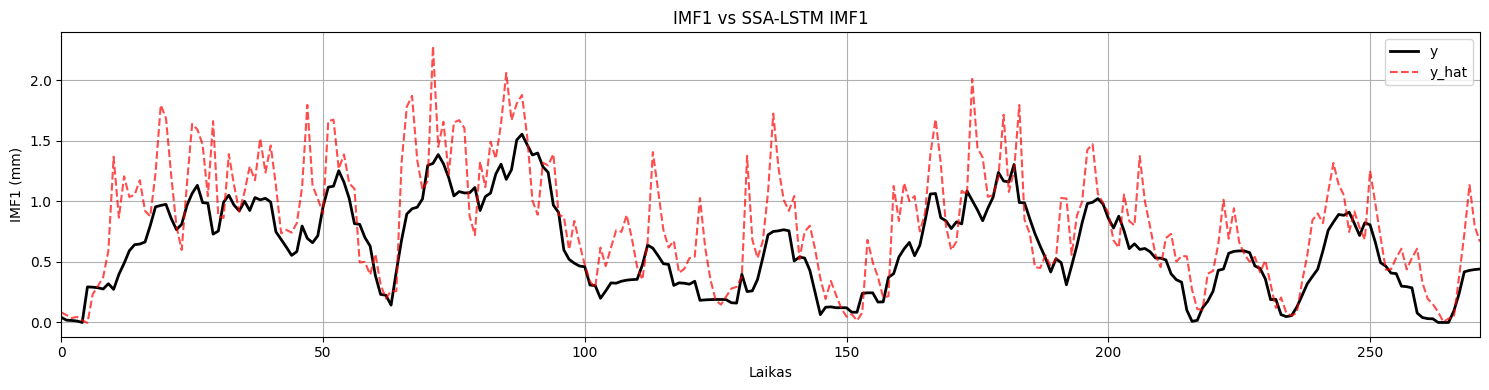

In [803]:
plt.figure(figsize=(15, 4))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF1 vs SSA-LSTM IMF1")
plt.xlabel("Laikas")
plt.ylabel("IMF1 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF2

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7}

In [319]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=7,

    module__hidden_dim=128,
    module__num_layers=1,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=20, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1.0),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [320]:
pipeline.fit(X_train_IMF2.values, y_train['IMF2'].values)
pred = pipeline.predict(X_test_IMF2.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0078        0.0024     +  0.2585
      2        0.0024        0.0023     +  0.1734
      3        0.0019        0.0016     +  0.1335
      4        0.0014        0.0014     +  0.1317
      5        0.0010        0.0010     +  0.1198
      6        0.0008        0.0007     +  0.1249
      7        0.0006        0.0005     +  0.1185
      8        0.0005        0.0004     +  0.1119
      9        0.0005        0.0005        0.1088
     10        0.0005        0.0008        0.1231
     11        0.0005        0.0010        0.1112
     12        0.0004        0.0009        0.1078
     13        0.0004        0.0008        0.1080
     14        0.0004        0.0007        0.1037
     15        0.0004        0.0006        0.1028
     16        0.0004        0.0004        0.1136
     17        0.0004        0.0006        0.1160
     18        0.0004        0.0010        0.1232


In [318]:
param_grid = {
    'window_size': [3, 5, 7],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF2.values, y_train['IMF2'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF2.values)

Fitting 2 folds for each of 108 candidates, totalling 216 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0159        0.0128     +  0.0997
      2        0.0066        0.0075     +  0.1024
      3        0.0041        0.0053     +  0.0904
      4        0.0029        0.0043     +  0.0692
      5        0.0023        0.0036     +  0.0718
      6        0.0018        0.0034     +  0.0751
      7        0.0015        0.0031     +  0.0673
      8        0.0012        0.0030     +  0.0731
      9        0.0010        0.0030     +  0.0691
     10        0.0009        0.0030        0.0644
     11        0.0008        0.0030     +  0.0709
     12        0.0007        0.0030        0.0623
     13        0.0006        0.0031        0.0677
     14        0.0005        0.0033        0.0715
     15        0.0005        0.0031        0.0776
     16        0.0005        0.0027     +  0.0775
     17        0.0011        0.0031  

c:\Users\crist\miniconda3\envs\ts_stable\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
2 fits failed out of a total of 216.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\crist\miniconda3\envs\ts_stable\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\crist\AppData\Local\Temp\ipykernel_3668\1073286227.py", line 71, in fit
    return super().fit(X_seq, y_trunc, **fit_params)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\crist\miniconda3\envs\ts_stable\Lib\site-packages\skorch\regressor.

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0084        0.0032     +  0.1111
      2        0.0026        0.0017     +  0.1093
      3        0.0013        0.0014     +  0.1023
      4        0.0009        0.0009     +  0.1061
      5        0.0005        0.0007     +  0.1056
      6        0.0003        0.0005     +  0.1067
      7        0.0003        0.0005        0.1040
      8        0.0003        0.0004     +  0.1033
      9        0.0004        0.0010        0.0934
     10        0.0005        0.0005        0.1264
     11        0.0004        0.0011        0.1098
     12        0.0010        0.0009        0.1045
     13        0.0006        0.0004        0.1089
     14        0.0006        0.0005        0.1063
     15        0.0003        0.0004     +  0.1123
     16        0.0003        0.0003     +  0.1090
     17        0.0004        0.0004        0.1090
     18        0.0004        0.0004        0.1070


In [321]:
y_true = y_test['IMF2'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[7:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF2 = y_true[7:]
y_pred_IMF2 = y_pred[7:]

RMSE:     0.2598
MAE:      0.2031
R2:       0.4958
Spearman: 0.7545


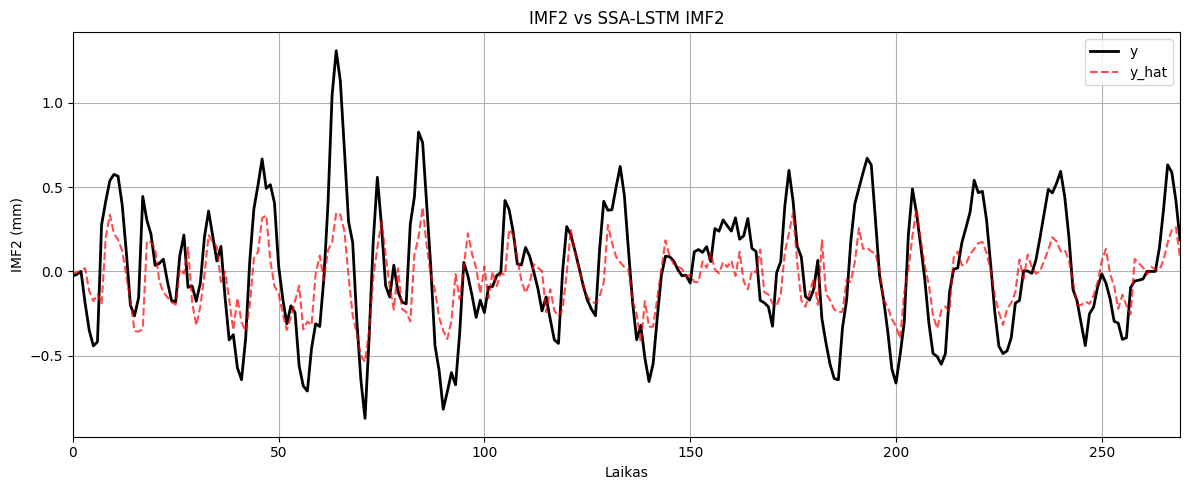

In [322]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF2 vs SSA-LSTM IMF2")
plt.xlabel("Laikas")
plt.ylabel("IMF2 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF3

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 5}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.4, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.3, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

In [617]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=3,

    module__hidden_dim=256,
    module__num_layers=2,
    module__dropout=0.3,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=64,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    # criterion=nn.HuberLoss(delta=1.0),
    criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [504]:
pipeline.fit(X_train_IMF3.values, y_train['IMF3_diff'].values)
pred = pipeline.predict(X_test_IMF3.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0067        0.0026     +  0.3417
      2        0.0016        0.0010     +  0.1319
      3        0.0006        0.0005     +  0.1374
      4        0.0004        0.0004     +  0.1313
      5        0.0004        0.0003     +  0.1493
      6        0.0003        0.0003        0.1498
      7        0.0003        0.0003     +  0.1289
      8        0.0003        0.0003        0.1550
      9        0.0003        0.0003        0.1636
     10        0.0002        0.0003     +  0.1475
     11        0.0003        0.0004        0.1497
     12        0.0003        0.0005        0.1323
     13        0.0004        0.0006        0.1400
     14        0.0003        0.0004        0.1416
     15        0.0003        0.0003        0.1322
     16        0.0005        0.0007        0.1328
     17        0.0006        0.0006        0.1307
     18        0.0004        0.0006        0.1384


In [474]:
param_grid = {
    'window_size': [3, 5],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.3, 0.4],
    'batch_size': [32, 64],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF3.values, y_train['IMF3'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF3.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0181        0.0075     +  0.1272
      2        0.0046        0.0033     +  0.1208
      3        0.0022        0.0027     +  0.1090
      4        0.0016        0.0020     +  0.0959
      5        0.0014        0.0018     +  0.0850
      6        0.0012        0.0018        0.0808
      7        0.0010        0.0018     +  0.0780
      8        0.0010        0.0013     +  0.0749
      9        0.0009        0.0018        0.0801
     10        0.0007        0.0014        0.0770
     11        0.0010        0.0017        0.0779
     12        0.0014        0.0022        0.0770
     13        0.0015        0.0014        0.0858
     14        0.0007        0.0013     +  0.0799
     15        0.0004        0.0010     +  0.0748
     16        0.0002        0.0009     +  0.0774
     17        0.0002        0.0008    

In [508]:
y_true = y_test['IMF3_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)
# y_pred = np.expm1(y_pred)

# Sulygiuojame ilgius
# min_len = min(len(y_true), len(y_pred))
# y_true = y_true[:min_len]
# y_pred = y_pred[:min_len]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF3 = y_true[11:]
y_pred_IMF3 = y_pred[11:]

RMSE:     0.1821
MAE:      0.1390
R2:       0.4829
Spearman: 0.7054


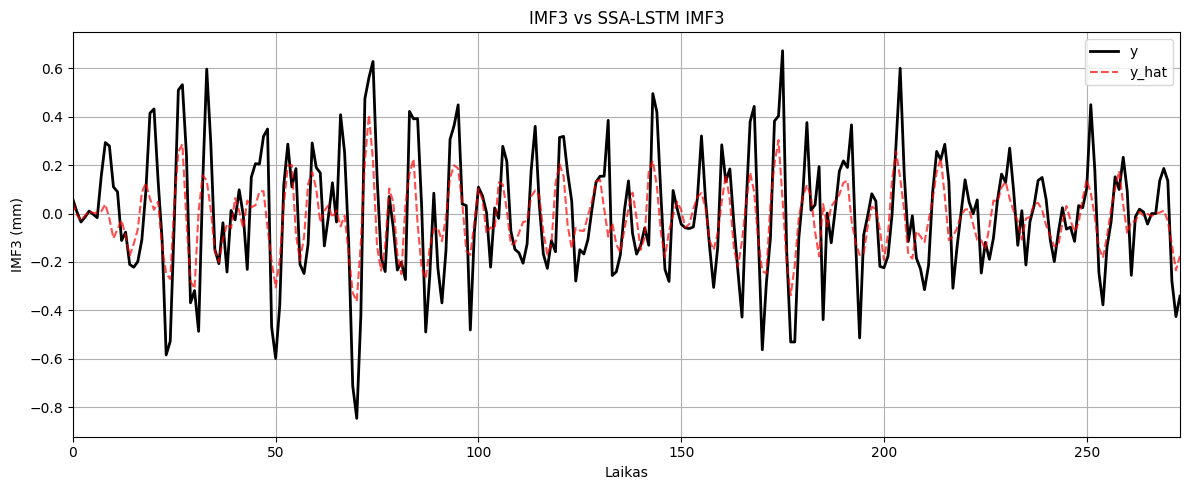

In [509]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF3 vs SSA-LSTM IMF3")
plt.xlabel("Laikas")
plt.ylabel("IMF3 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF4

In [623]:
class LSTMFCRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Vietoj vieno fc sluoksnio, naudojame Sequential bloką su LeakyReLU.
        # Tai padeda modeliui "ištraukti" triukšmo pikus, kurių paprastas fc nepagautų.
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.1), 
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        # Naudojame paskutinį laiko žingsnį
        return self.fc(out[:, -1, :])

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 3}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 3}

In [857]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=3,

    module__hidden_dim=128,
    module__num_layers=2,
    module__dropout=0.1,
    optimizer__weight_decay = 0,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=12, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=nn.HuberLoss(delta=0.6),
    criterion=nn.L1Loss(),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [858]:
pipeline.fit(X_train_IMF4.values, y_train['IMF4_diff'].values)
pred = pipeline.predict(X_test_IMF4.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0860        0.0555     +  0.4467
      2        0.0514        0.0467     +  0.2915
      3        0.0435        0.0268     +  0.2997
      4        0.0258        0.0297        0.2421
      5        0.0209        0.0207     +  0.2411
      6        0.0220        0.0173     +  0.2337
      7        0.0188        0.0155     +  0.2327
      8        0.0202        0.0153     +  0.2395
      9        0.0165        0.0186        0.2717
     10        0.0188        0.0178        0.2757
     11        0.0181        0.0215        0.2549
     12        0.0160        0.0182        0.2490
     13        0.0174        0.0127     +  0.3176
     14        0.0181        0.0198        0.2635
     15        0.0160        0.0238        0.2622
     16        0.0177        0.0160        0.2537
     17        0.0179        0.0241        0.2414
     18        0.0146        0.0145        0.2523


In [ ]:
param_grid = {
    'window_size': [3, 5],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF4.values, y_train['IMF4_diff'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF4.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.1278        0.1320     +  0.1701
      2        0.0820        0.0660     +  0.1568
      3        0.0502        0.0534     +  0.1478
      4        0.0744        0.0747        0.1240
      5        0.0484        0.0446     +  0.1268
      6        0.0404        0.0461        0.1248
      7        0.0346        0.0383     +  0.1257
      8        0.0364        0.0570        0.1188
      9        0.0495        0.0339     +  0.1391
     10        0.0260        0.0310     +  0.1380
     11        0.0233        0.0320        0.1574
     12        0.0310        0.0276     +  0.1477
     13        0.0239        0.0331        0.1549
     14        0.0268        0.0373        0.1522
     15        0.0247        0.0264     +  0.1525
     16        0.0227        0.0306        0.1669
     17        0.0270        0.0272    

In [1]:
y_true = y_test['IMF4_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[3:]
y_pred = np.array(pred).reshape(-1)[:]
# y_pred = np.expm1(y_pred)


rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF4 = y_true[11:]
y_pred_IMF4 = y_pred[11:]

NameError: name 'y_test' is not defined

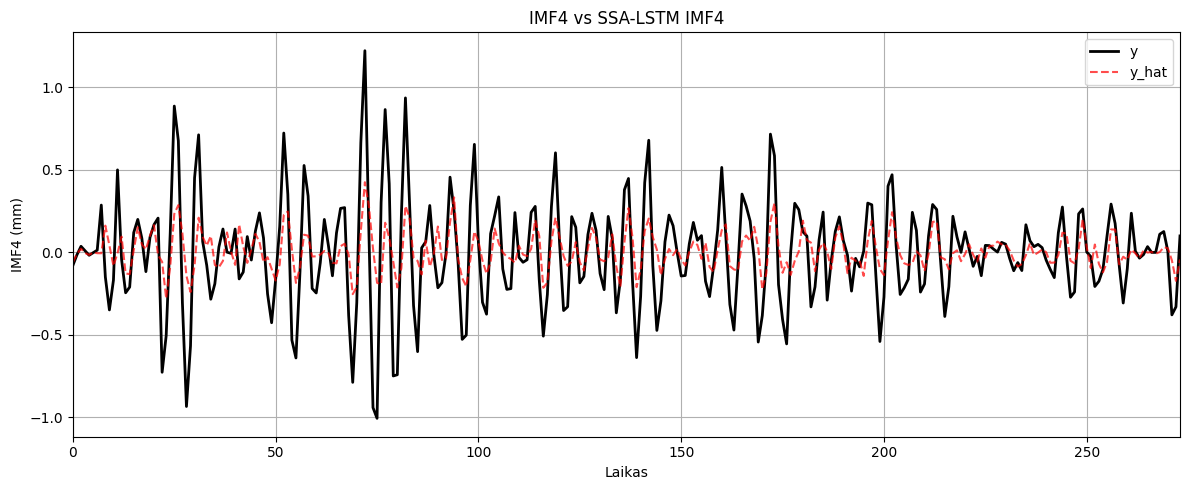

In [854]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF4 vs SSA-LSTM IMF4")
plt.xlabel("Laikas")
plt.ylabel("IMF4 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF5

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 64, 'module__num_layers': 2, 'window_size': 5}

In [654]:
pipeline = LSTMNet(
    base_module=LSTMRegressor,
    window_size=5,

    module__hidden_dim=64,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=16,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=3),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [655]:
pipeline.fit(X_train_IMF5.values, y_train['IMF5'].values)
pred = pipeline.predict(X_test_IMF5.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0076        0.0029     +  0.5232
      2        0.0013        0.0007     +  0.4125
      3        0.0006        0.0005     +  0.3908
      4        0.0005        0.0003     +  0.3971
      5        0.0004        0.0003     +  0.3994
      6        0.0003        0.0003        0.3809
      7        0.0003        0.0003        0.4021
      8        0.0003        0.0002     +  0.3887
      9        0.0003        0.0004        0.4278
     10        0.0002        0.0003        0.3831
     11        0.0003        0.0002     +  0.3749
     12        0.0003        0.0002        0.3740
     13        0.0002        0.0003        0.4033
     14        0.0003        0.0004        0.3989
     15        0.0002        0.0003        0.3693
     16        0.0002        0.0003        0.3692
     17        0.0003        0.0003        0.3703
     18        0.0002        0.0002        0.3836


In [287]:
param_grid = {
    'window_size': [2, 3, 5],
    'module__hidden_dim': [64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2, 0.3],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF5.values, y_train['IMF5'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF5.values)

Fitting 2 folds for each of 108 candidates, totalling 216 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0098        0.0126     +  0.1664
      2        0.0091        0.0123     +  0.1944
      3        0.0087        0.0119     +  0.1602
      4        0.0086        0.0119     +  0.1402
      5        0.0085        0.0118     +  0.1242
      6        0.0083        0.0117     +  0.1243
      7        0.0082        0.0116     +  0.1200
      8        0.0081        0.0115     +  0.1232
      9        0.0080        0.0115     +  0.1235
     10        0.0079        0.0115     +  0.1235
     11        0.0078        0.0115     +  0.1301
     12        0.0078        0.0115        0.1278
     13        0.0078        0.0115        0.1265
     14        0.0077        0.0115     +  0.1199
     15        0.0076        0.0114     +  0.1371
     16        0.0075        0.0116        0.1315
     17        0.0075        0.0117  

In [660]:
y_true = y_test['IMF5'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[5:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF5 = y_true[9:]
y_pred_IMF5 = y_pred[9:]

RMSE:     0.2660
MAE:      0.2015
R2:       0.4049
Spearman: 0.7093


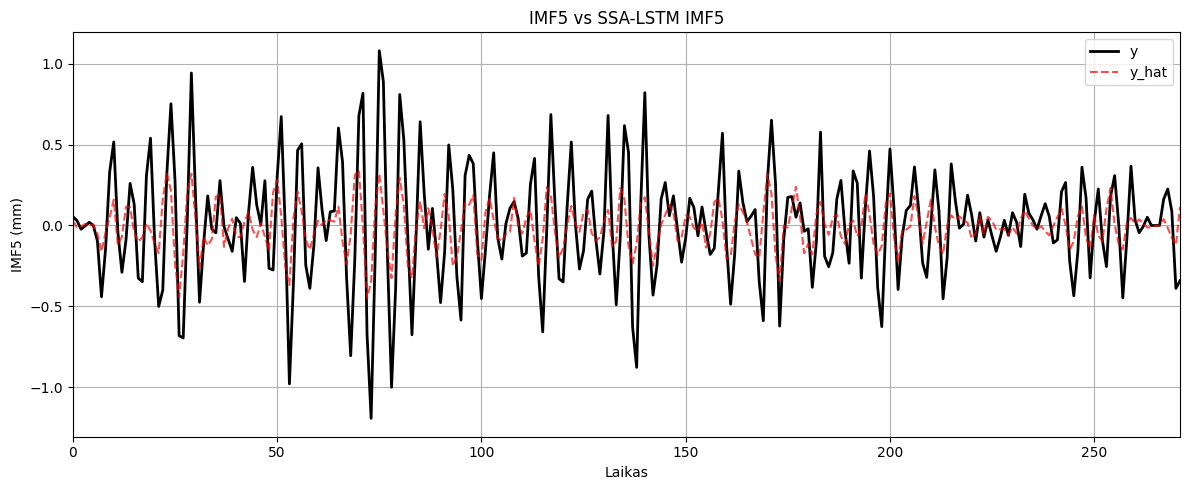

In [659]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF5 vs SSA-LSTM IMF5")
plt.xlabel("Laikas")
plt.ylabel("IMF5 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF6

{'batch_size': 64, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 14}

{'batch_size': 16, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 7}

In [725]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=7,

    module__hidden_dim=256,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=10, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [727]:
pipeline.fit(X_train_IMF6.values, y_train['IMF6_diff'].values)
pred = pipeline.predict(X_test_IMF6.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0102        0.0072     +  0.4613
      2        0.0037        0.0016     +  0.3252
      3        0.0013        0.0010     +  0.3515
      4        0.0008        0.0005     +  0.3454
      5        0.0006        0.0005        0.3514
      6        0.0005        0.0005        0.3449
      7        0.0007        0.0006        0.3465
      8        0.0005        0.0004     +  0.3452
      9        0.0005        0.0006        0.3415
     10        0.0005        0.0004        0.3360
     11        0.0004        0.0004        0.3374
     12        0.0005        0.0005        0.4311
     13        0.0006        0.0011        0.3443
     14        0.0008        0.0006        0.4259
     15        0.0008        0.0007        0.3707
     16        0.0006        0.0007        0.3215
     17        0.0005        0.0005        0.3394
Stopping since valid_loss has not improved in the 

In [358]:
param_grid = {
    'window_size': [5, 7],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [16, 32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF6.values, y_train['IMF6'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF6.values)

Fitting 2 folds for each of 32 candidates, totalling 64 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0059        0.0123     +  0.2502
      2        0.0121        0.0113     +  0.2480
      3        0.0045        0.0031     +  0.1873
      4        0.0023        0.0022     +  0.1742
      5        0.0016        0.0018     +  0.1487
      6        0.0009        0.0015     +  0.1461
      7        0.0007        0.0013     +  0.1444
      8        0.0006        0.0012     +  0.1406
      9        0.0005        0.0013        0.1378
     10        0.0004        0.0013        0.1377
     11        0.0004        0.0012     +  0.1375
     12        0.0003        0.0011     +  0.1412
     13        0.0003        0.0017        0.1433
     14        0.0005        0.0027        0.1594
     15        0.0006        0.0013        0.1500
     16        0.0006        0.0027        0.1554
     17        0.0011        0.0021    

In [732]:
y_true = y_test['IMF6_diff'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[7:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF6 = y_true[7:]
y_pred_IMF6 = y_pred[7:]

RMSE:     0.3326
MAE:      0.2607
R2:       0.5853
Spearman: 0.7370


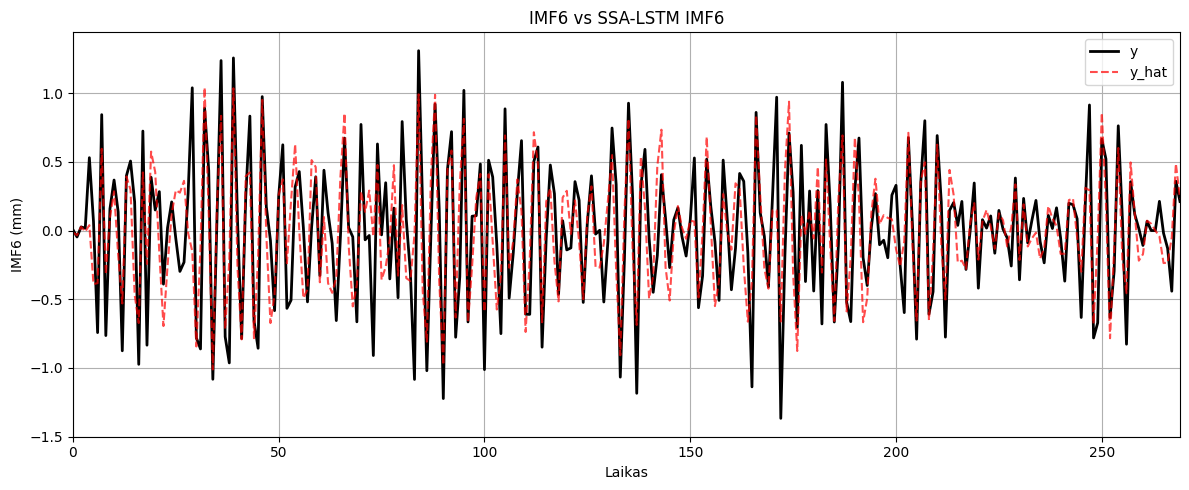

In [733]:
plt.figure(figsize=(12, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF6 vs SSA-LSTM IMF6")
plt.xlabel("Laikas")
plt.ylabel("IMF6 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF7

{'batch_size': 32, 'lr': 0.01, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 5}

 {'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 256, 'module__num_layers': 1, 'window_size': 5}

In [737]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=5,

    module__hidden_dim=256,
    module__num_layers=1,
    module__dropout=0.1,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.01,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=1),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [738]:
pipeline.fit(X_train_IMF7.values, y_train['IMF7'].values)
pred = pipeline.predict(X_test_IMF7.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0153        0.0083     +  0.3534
      2        0.0060        0.0039     +  0.2401
      3        0.0028        0.0014     +  0.2947
      4        0.0014        0.0018        0.2537
      5        0.0019        0.0033        0.2471
      6        0.0034        0.0028        0.2264
      7        0.0022        0.0022        0.2357
      8        0.0020        0.0009     +  0.2564
      9        0.0011        0.0016        0.2487
     10        0.0014        0.0015        0.2435
     11        0.0010        0.0011        0.2490
     12        0.0006        0.0011        0.2269
     13        0.0006        0.0013        0.2344
     14        0.0008        0.0019        0.2006
     15        0.0011        0.0019        0.2533
     16        0.0012        0.0016        0.2387
     17        0.0011        0.0021        0.2287
     18        0.0012        0.0025        0.2216


In [364]:
param_grid = {
    'window_size': [5, 7],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],          
    'module__dropout': [0.1, 0.2],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF7.values, y_train['IMF7'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF7.values)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0111        0.0078     +  0.1458
      2        0.0080        0.0063     +  0.1244
      3        0.0061        0.0051     +  0.1193
      4        0.0047        0.0040     +  0.0935
      5        0.0030        0.0027     +  0.0868
      6        0.0016        0.0019     +  0.0971
      7        0.0011        0.0017     +  0.1026
      8        0.0010        0.0014     +  0.0954
      9        0.0008        0.0023        0.0952
     10        0.0010        0.0016        0.0842
     11        0.0008        0.0024        0.1042
     12        0.0006        0.0012     +  0.0922
     13        0.0004        0.0010     +  0.0843
     14        0.0003        0.0010        0.0797
     15        0.0003        0.0011        0.0868
     16        0.0002        0.0010     +  0.0906
     17        0.0002        0.0010    

In [743]:
y_true = y_test['IMF7'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[5:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF7 = y_true[9:]
y_pred_IMF7 = y_pred[9:]

RMSE:     0.2029
MAE:      0.1558
R2:       0.1141
Spearman: 0.4138


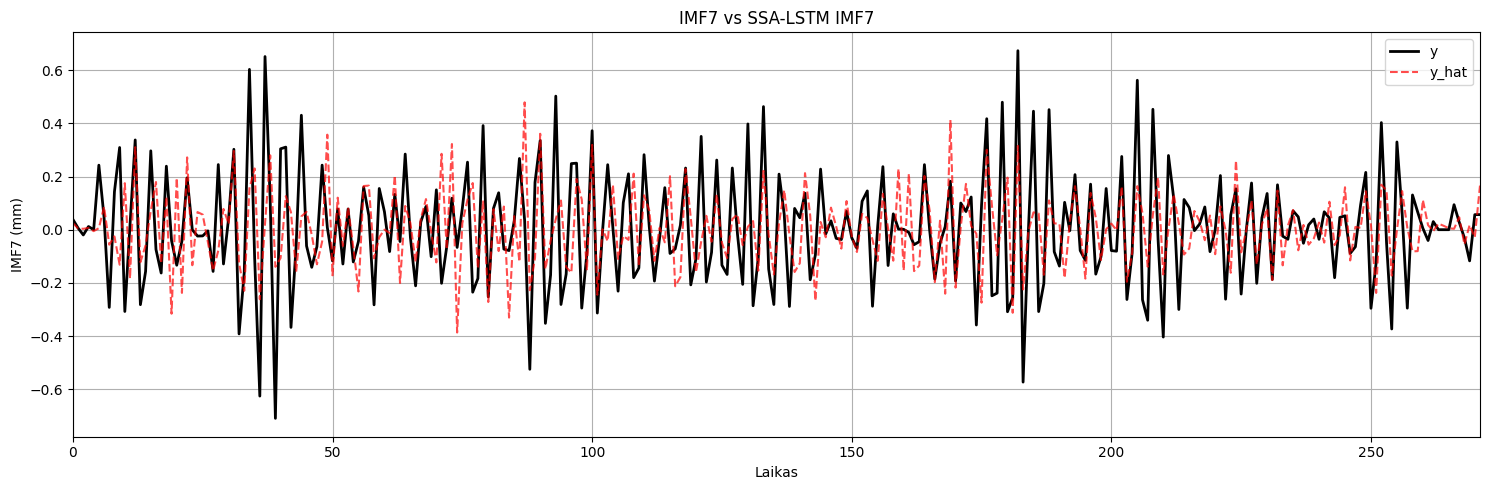

In [744]:
plt.figure(figsize=(15, 5))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF7 vs SSA-LSTM IMF7")
plt.xlabel("Laikas")
plt.ylabel("IMF7 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## IMF8

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.1, 'module__hidden_dim': 128, 'module__num_layers': 2, 'window_size': 14}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 128, 'module__num_layers': 1, 'window_size': 7}

{'batch_size': 32, 'lr': 0.001, 'module__dropout': 0.2, 'module__hidden_dim': 256, 'module__num_layers': 2, 'window_size': 7}

In [748]:
pipeline = LSTMNet(
    base_module=LSTMFCRegressor,
    window_size=7,

    module__hidden_dim=256,
    module__num_layers=2,
    module__dropout=0.2,

    callbacks=[
        ('early_stopping', EarlyStopping(patience=15, monitor='valid_loss')),
        ('checkpoint', Checkpoint(monitor='valid_loss_best', load_best=True))
    ],

    max_epochs=1000,
    lr=0.001,
    batch_size=32,
    optimizer=torch.optim.Adam,
    # criterion=TweedieLoss(p=1.5),
    criterion=nn.HuberLoss(delta=0.5),
    # criterion=nn.MSELoss(),
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

In [749]:
pipeline.fit(X_train_IMF8.values, y_train['IMF8'].values)
pred = pipeline.predict(X_test_IMF8.values)

  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0380        0.0271     +  0.5514
      2        0.0160        0.0117     +  0.3416
      3        0.0092        0.0060     +  0.3275
      4        0.0059        0.0061        0.3425
      5        0.0051        0.0042     +  0.3584
      6        0.0042        0.0048        0.3619
      7        0.0038        0.0055        0.3300
      8        0.0047        0.0044        0.3489
      9        0.0044        0.0050        0.3566
     10        0.0044        0.0053        0.3252
     11        0.0035        0.0060        0.2917
     12        0.0033        0.0062        0.3474
     13        0.0034        0.0059        0.3736
     14        0.0032        0.0058        0.3068
     15        0.0031        0.0046        0.3018
     16        0.0034        0.0048        0.3063
     17        0.0025        0.0051        0.3036
     18        0.0031        0.0043        0.3335


In [371]:
param_grid = {
    'window_size': [5, 7],
    'module__hidden_dim': [128, 256],
    'module__num_layers': [1, 2],
    'lr': [0.001],
    'module__dropout': [0.2, 0.3],
    'batch_size': [32],
}
tscv = TimeSeriesSplit(n_splits=2)

def rmse_for_sequences(y_true, y_pred, **kwargs):
    diff = len(y_true) - len(y_pred)
    return root_mean_squared_error(y_true[diff:], y_pred)

custom_rmse = make_scorer(rmse_for_sequences, greater_is_better=False)

gs = GridSearchCV(
    pipeline, 
    param_grid, 
    refit=True, 
    cv=tscv,
    scoring=custom_rmse, 
    verbose=2
)

gs.fit(X_train_IMF8.values, y_train['IMF8'].values)
print("Geriausi parametrai:", gs.best_params_)
print("Geriausias rezultatas (MSE):", -gs.best_score_)

pred = gs.predict(X_test_IMF8.values)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
  epoch    train_loss    valid_loss    cp     dur
-------  ------------  ------------  ----  ------
      1        0.0500        0.0423     +  0.1337
      2        0.0443        0.0365     +  0.1254
      3        0.0385        0.0307     +  0.1300
      4        0.0309        0.0277     +  0.1104
      5        0.0271        0.0362        0.1013
      6        0.0273        0.0272     +  0.1018
      7        0.0208        0.0239     +  0.0833
      8        0.0162        0.0229     +  0.0938
      9        0.0132        0.0251        0.0847
     10        0.0120        0.0284        0.0834
     11        0.0109        0.0250        0.0969
     12        0.0110        0.0306        0.0858
     13        0.0099        0.0214     +  0.0826
     14        0.0065        0.0181     +  0.0868
     15        0.0051        0.0171     +  0.0859
     16        0.0043        0.0168     +  0.0980
     17        0.0034        0.0179    

In [754]:
y_true = y_test['IMF8'].values.astype(float)
# y_true = np.expm1(y_true)

y_true = y_true[7:]
y_pred = np.array(pred).reshape(-1)[:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
spearman_corr, _ = spearmanr(y_true, y_pred)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

y_true_IMF8 = y_true[7:]
y_pred_IMF8 = y_pred[7:]

RMSE:     0.3187
MAE:      0.2517
R2:       -0.7281
Spearman: 0.4461


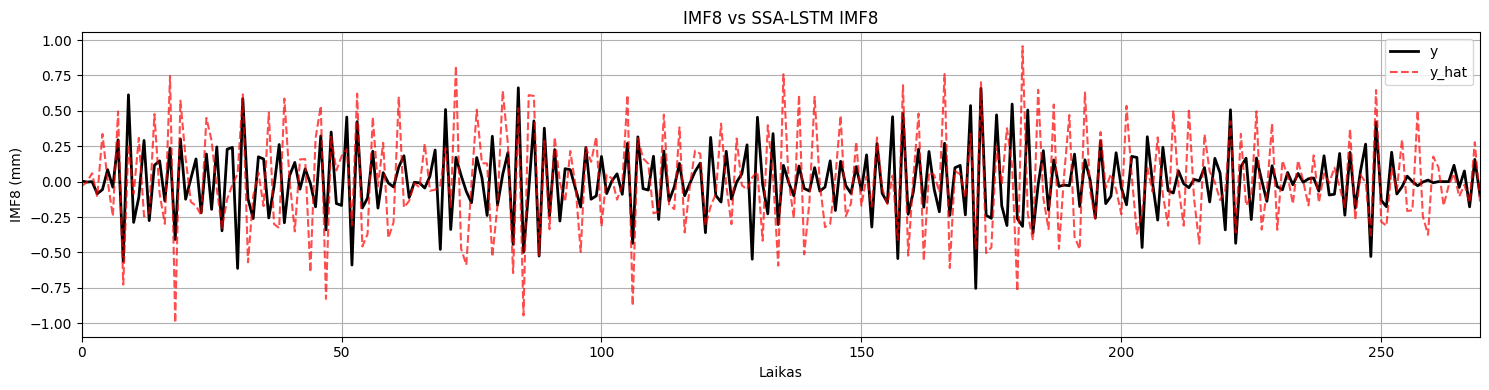

In [755]:
plt.figure(figsize=(15, 4))
plt.plot(y_true, label="y", linewidth=2, color='black')
plt.plot(y_pred, label="y_hat", linewidth=1.5, alpha=0.7, color='red', linestyle='--')
plt.xlim(0, len(y_true) - 1)
plt.title("IMF8 vs SSA-LSTM IMF8")
plt.xlabel("Laikas")
plt.ylabel("IMF8 (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## SSA-LSTM rezultatai

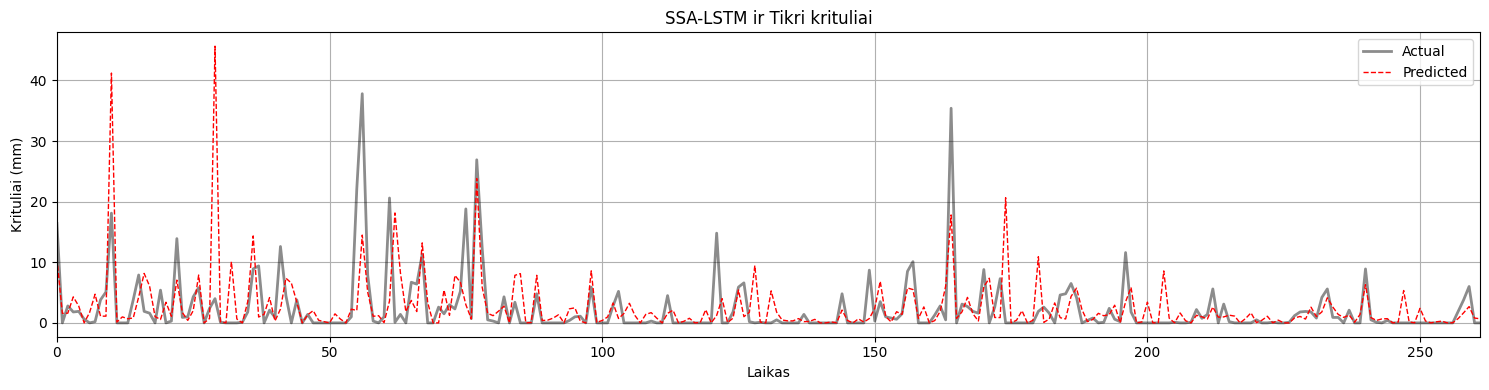

In [843]:
y_pred_IMF3_lvl = X_test_raw['IMF3'].values[14:] + y_pred_IMF3

y_pred_IMF4_lvl = X_test_raw['IMF4'].values[14:] + y_pred_IMF4

y_pred_IMF6_lvl = X_test_raw['IMF6'].values[14:] + y_pred_IMF6

y_true_final = np.expm1(y_original_imf['IMF1'].values.astype(float) + 
                        y_original_imf['IMF2'].values.astype(float) + 
                        y_original_imf['IMF3'].values.astype(float) + 
                        y_original_imf['IMF4'].values.astype(float) + 
                        y_original_imf['IMF5'].values.astype(float) + 
                        y_original_imf['IMF6'].values.astype(float) + 
                        y_original_imf['IMF7'].values.astype(float) + 
                        y_original_imf['IMF8'].values.astype(float))[14:]
y_pred_final = np.expm1(y_pred_IMF1[:] + y_pred_IMF2[:] + y_pred_IMF3_lvl[:] + y_pred_IMF4_lvl[:] + y_pred_IMF5 + y_pred_IMF6_lvl[:] + y_pred_IMF7 + y_pred_IMF8)[:].clip(min=0)
y_actual_precipitation = data['missforest_precipitation'][(int(len(data)*0.9) + 14):-1].values

plt.figure(figsize=(15, 4))
plt.plot(y_actual_precipitation, label="Actual", linewidth=2, alpha=0.45, color = 'black')
# plt.plot(y_true_final, label="True", linewidth=1.2, alpha = 0.8)
plt.plot(y_pred_final, label="Predicted", linewidth=1, alpha=1, color='red', linestyle='--')
plt.xlim(0, len(y_actual_precipitation) - 1)
plt.title("SSA-LSTM ir Tikri krituliai")
plt.xlabel("Laikas")
plt.ylabel("Krituliai (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [833]:
rmse = np.sqrt(mean_squared_error(y_true_final, y_pred_final))
mae  = mean_absolute_error(y_true_final, y_pred_final)
r2   = r2_score(y_true_final, y_pred_final)
spearman_corr, _ = spearmanr(y_true_final, y_pred_final)

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     5.1265
MAE:      2.4843
R2:       -0.0561
Spearman: 0.5134


In [847]:
rmse = np.sqrt(mean_squared_error(y_actual_precipitation, y_pred_final[:-1]))
mae  = mean_absolute_error(y_actual_precipitation, y_pred_final[:-1])
r2   = r2_score(y_actual_precipitation, y_pred_final[:-1])
spearman_corr, _ = spearmanr(y_actual_precipitation, y_pred_final[:-1])

print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R2:       {r2:.4f}")
print(f"Spearman: {spearman_corr:.4f}")

RMSE:     5.1363
MAE:      2.4928
R2:       -0.0569
Spearman: 0.5036
